# Quantum Paint Quick Start Guide

In [1]:
import quantumblur as qb
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
from PIL import Image

We are going to create an image using quantum gates from a blank canvas, which means from an empty circuit. Let's start with 6 qubits.

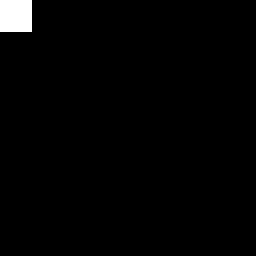

In [2]:
n = 6

qc = QuantumCircuit(n)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

Why is that one pixel bright? It's all to do with coordinates.

There are $2^{n}$ pixels in total, split into $2^{n/2}$ rows and $2^{n/2}$ columns (at least when $n$ is even). The rows (and columns) are labelled with the following bit strings.

In [3]:
qb.make_line(2**(n//2))

['000', '100', '110', '010', '011', '111', '101', '001']

Each pixel is then labelled by a string of $n$ bits, made up of column coordinate + row coordinate.

The top left pixel is the origin, and hence represents the `000000` outcome of the blank circuit.

If we add an `x`, we can move the pixel.

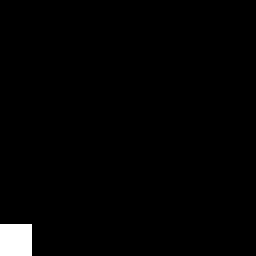

In [4]:
qc = QuantumCircuit(n)
qc.x(0)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

It is now at the bottom left because the resulting bit string is `000001`, which is column `000` and row `001`.

The coordinates are built up using a principle of reflection and concatenation.

Let's start with the values for one bit.

    0 1

To create a list of all strings for two bits we first reflect the single bit strings

    0 1 1 0

The originals then have a `0` concatenated on the right, and the reflections get a `1`.

    00 10 11 01

This gives us a list of all possible two-bit strings, but in an order such that each differs by only a single bit flip from its neighbours.

For three-bit strings we again reflect and concatenate

    000 100 110 010 011 111 101 001

And so on for strings with any number of bits.


This encoding means
* Flipping the first qubit (rightmost qubit) corresponds to a reflection of the whole image.
* Flipping the second qubit corresponds to separate reflections of each half.
* Flipping the third qubit corresponds to separate reflections of each quarter.



Now let's use these ideas to make an I in the style of the IBM logo.

Here's one I made earlier.

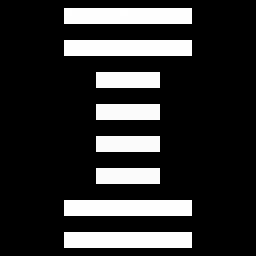

In [5]:
qc,_ = qb.dotdot(32)
qc = transpile(qc, AerSimulator())
qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

For this we need 10 qubits, and so the strings labelling the rows and columns will be 5 bits long.

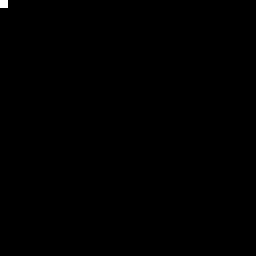

In [6]:
n = 10

qc = QuantumCircuit(n)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

First we use the reflection around the horizontal halves to move the pixel to the middle.

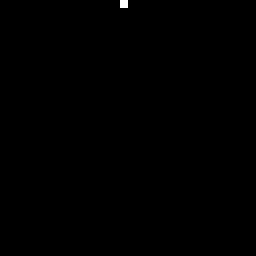

In [7]:
n = 10

qc = QuantumCircuit(n)
qc.x(n//2 + 1)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

Then we use the reflection between each pair of 32ths to move it one pixel down.

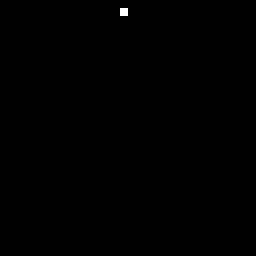

In [8]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

Then a partial relflection around vertical 16ths doubles the pattern.

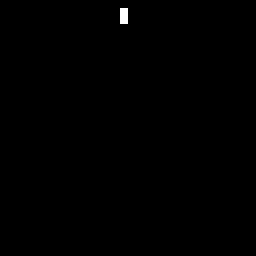

In [9]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qc.rx(np.pi/2, 3)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

With a reflection around vertical 8ths we copy it.

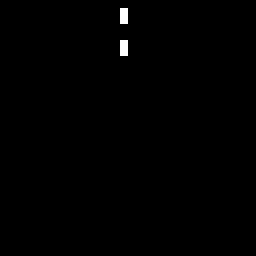

In [10]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qc.rx(np.pi/2, 3)
qc.rx(np.pi/2, 2)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

Then using the vertical quarters we copy again, but this time we use a smaller angle to have less brightness in the middle.

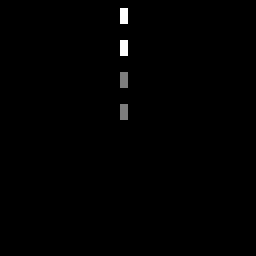

In [11]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qc.rx(np.pi/2, 3)
qc.rx(np.pi/2, 2)
qc.rx(0.39*np.pi, 1)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

Now reflect down to the bottom.

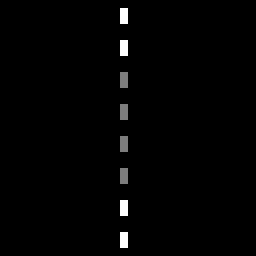

In [12]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qc.rx(np.pi/2, 3)
qc.rx(np.pi/2, 2)
qc.rx(0.39*np.pi, 1)
qc.rx(np.pi/2, 0)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

Now we make this symettric vertically.

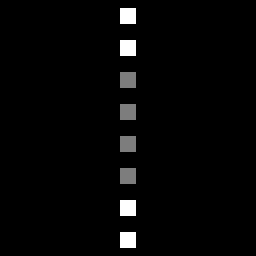

In [13]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qc.rx(np.pi/2, 3)
qc.rx(np.pi/2, 2)
qc.rx(0.39*np.pi, 1)
qc.rx(np.pi/2, 0)

qc.rx(np.pi/2, n//2+0)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

And unfold vertically some more.

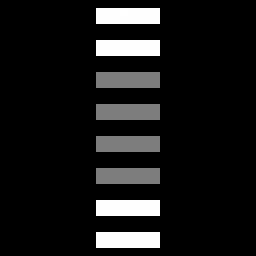

In [14]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qc.rx(np.pi/2, 3)
qc.rx(np.pi/2, 2)
qc.rx(0.39*np.pi, 1)
qc.rx(np.pi/2, 0)

qc.rx(np.pi/2, n//2+0)
qc.rx(np.pi/2, n//2+4)
qc.rx(np.pi/2, n//2+3)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)

Then we unfold vertically only on those lines for which qubit 1 is in the state `0`. This corresponds to the horizontal bars that will form the top and bottom of the I, and therefore the ones that have been brighter up to now. By spreading out the brightness over larger bars, all pixels will become equally bright.

This requires a controlled `rx`, but controlled on which qubit. To find out, consider the following visualization of the coordinate for each row. Here each row represents a bit string, with light grey representing `1` and dark grey representing `0`.

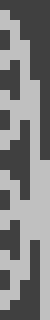

In [15]:
img = Image.new('RGB', (n//2, 2**(n//2)))

line = qb.make_line(2**(n//2))

for x in range(n//2):
    for y in range(2**(n//2)):
        b = 128*int(line[y][x])+64
        img.putpixel((x,y), (b,b,b) )

img.resize((10*img.size[0],10*img.size[1]), 0)

Here we see that qubit 0 (the rightmost) is `0` for the top half of the image and `1` for the bottom. Qubit 1 is `0` for the top and bottom quarters but `1` for the middle. This is what we need. If we control a reflection on the `0` state of qubit 1, we can apply a reflection to only the top and bottom of the image.

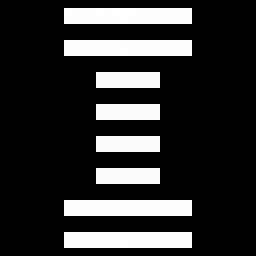

In [16]:
qc = QuantumCircuit(n)

qc.x(n//2 + 1)
qc.x(4)

qc.rx(np.pi/2, 3)
qc.rx(np.pi/2, 2)
qc.rx(0.39*np.pi, 1)
qc.rx(np.pi/2, 0)

qc.rx(np.pi/2, n//2+0)
qc.rx(np.pi/2, n//2+4)
qc.rx(np.pi/2, n//2+3)

qc.x(1)
qc.crx(np.pi/2,1,n//2+2)
qc.x(1)

qb.height2image(qb.circuit2height(qc)).resize((256,256),0)